In [10]:
# 1. Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [11]:
# 2. Basic parameters
LATENT_DIM = 2
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3

np.random.seed(42)
tf.random.set_seed(42)

In [12]:
# 3. Load and preprocess MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Training:", x_train.shape)
print("Test:", x_test.shape)

Training: (60000, 28, 28, 1)
Test: (10000, 28, 28, 1)


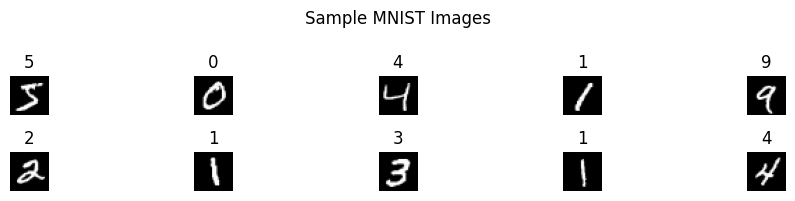

In [13]:
# 4. Display sample images
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(str(y_train[i]))
    plt.axis("off")
plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

In [14]:
# 5. Build the encoder
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder_inputs = keras.Input(shape=(28, 28, 1), name="encoder_input")
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(
    encoder_inputs, [z_mean, z_log_var, z], name="encoder"
)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 784)       │          0 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    200,960 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     32,896 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 234,372 (915.52 KB)

 Trainable params: 234,372 (915.52 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# 6. Build the decoder
latent_inputs = keras.Input(shape=(LATENT_DIM,), name="latent_input")

x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(28 * 28, activation="sigmoid")(x)
decoder_outputs = layers.Reshape((28, 28, 1))(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ latent_input (InputLayer)       │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,896 (917.56 KB)

 Trainable params: 234,896 (917.56 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# 8. Train the VAE for 20 epochs
EPOCHS = 20
BATCH_SIZE = 128

history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - kl_loss: 0.0031 - reconstruction_loss: 0.2858 - total_loss: 0.2889
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - kl_loss: 9.3664e-05 - reconstruction_loss: 0.2634 - total_loss: 0.2635
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - kl_loss: 2.6509e-05 - reconstruction_loss: 0.2633 - total_loss: 0.2633
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - kl_loss: 1.1301e-05 - reconstruction_loss: 0.2632 - total_loss: 0.2632
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - kl_loss: 6.1273e-06 - reconstruction_loss: 0.2632 - total_loss: 0.2632
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - kl_loss: 3.9769e-06 - reconstruction_loss: 0.2631 - total_loss: 0.2632
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - kl_loss: 2.8254e-06 - reconstruction_loss: 0.2631 - total_loss: 0.2631
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 2.3895e-06 - reconstruction_loss: 0.2631 - total_loss:

In [17]:
# 8. Train the VAE for 20 epochs
history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - kl_loss: 4.9455e-07 - reconstruction_loss: 0.2629 - total_loss: 0.2629
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - kl_loss: 3.2553e-07 - reconstruction_loss: 0.2629 - total_loss: 0.2629
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 3.5543e-07 - reconstruction_loss: 0.2629 - total_loss: 0.2629
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - kl_loss: 3.2293e-07 - reconstruction_loss: 0.2629 - total_loss: 0.2629
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 2.3874e-07 - reconstruction_loss: 0.2629 - total_loss: 0.2629
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - kl_loss: 2.7106e-07 - reconstruction_loss: 0.2629 - total_loss: 0.2629
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - kl_loss: 1.6783e-07 - reconstruction_loss: 0.2629 - total_loss: 0.2629
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - kl_loss: 2.4399e-07 - reconstruction_loss: 0.2629 - total_loss:

KeyError: 'loss'

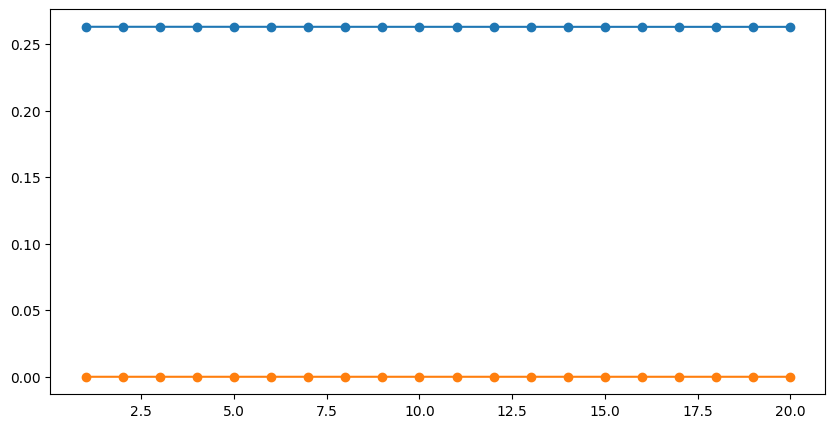

In [18]:
# 9. Plot reconstruction, KL and total loss separately
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 5))
plt.plot(
    epochs_range,
    history.history["reconstruction_loss"],
    marker="o",
    label="Reconstruction Loss",
)
plt.plot(
    epochs_range,
    history.history["kl_loss"],
    marker="o",
    label="KL Divergence Loss",
)
plt.plot(
    epochs_range,
    history.history["loss"],
    marker="o",
    label="Total Loss",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")
plt.legend()
plt.grid(True)
plt.show()

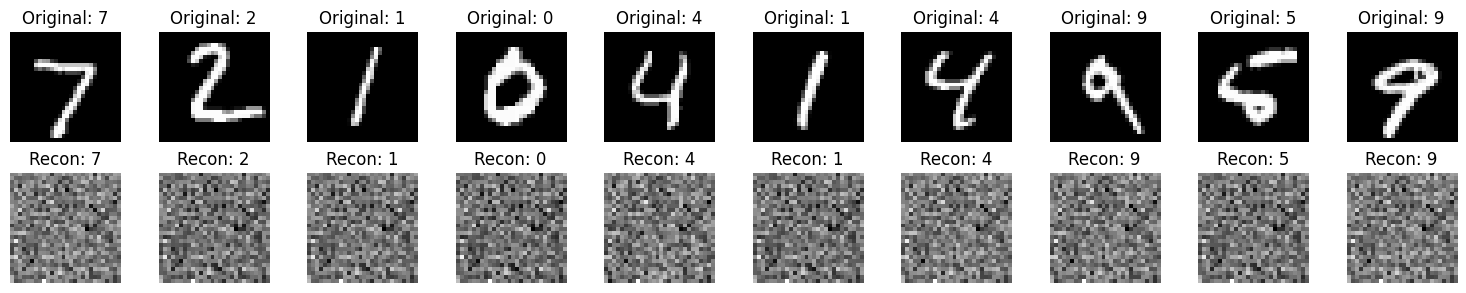

In [19]:
# 10. Original images vs reconstructed images
n = 10
original = x_test[:n]

z_mean_test, z_log_var_test, z_test = encoder.predict(
    original, verbose=0
)
reconstructed = decoder.predict(z_mean_test, verbose=0)

plt.figure(figsize=(15, 3))

for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(original[i].squeeze(), cmap="gray")
    plt.title(f"Original: {y_test[i]}")
    plt.axis("off")

    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.title(f"Recon: {y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


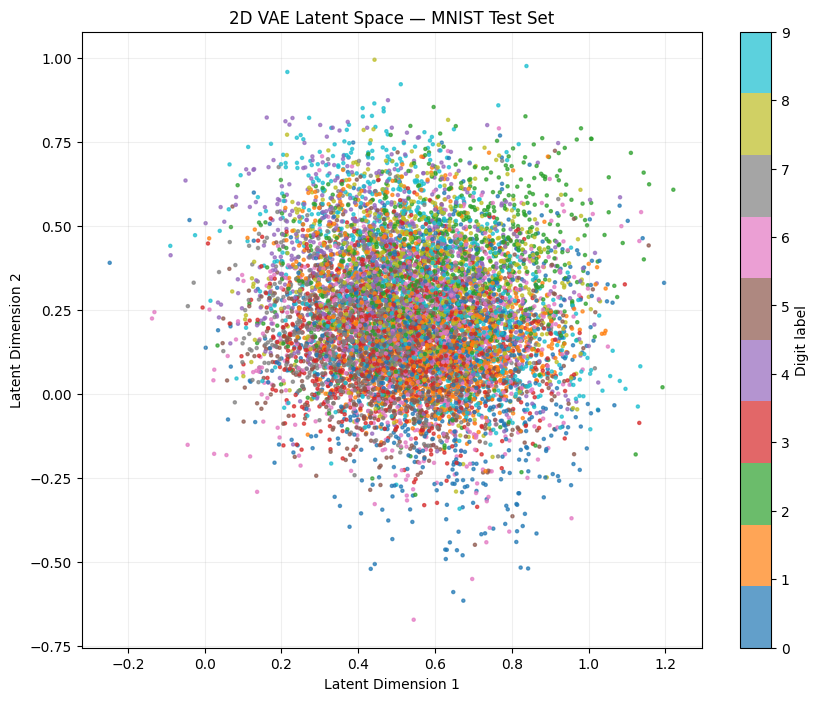

In [20]:
# 11. 2D latent-space scatter plot
z_mean_all, _, _ = encoder.predict(
    x_test, batch_size=BATCH_SIZE, verbose=1
)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    z_mean_all[:, 0],
    z_mean_all[:, 1],
    c=y_test,
    cmap="tab10",
    s=5,
    alpha=0.7,
)
plt.colorbar(scatter, ticks=range(10), label="Digit label")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D VAE Latent Space — MNIST Test Set")
plt.grid(alpha=0.2)
plt.show()

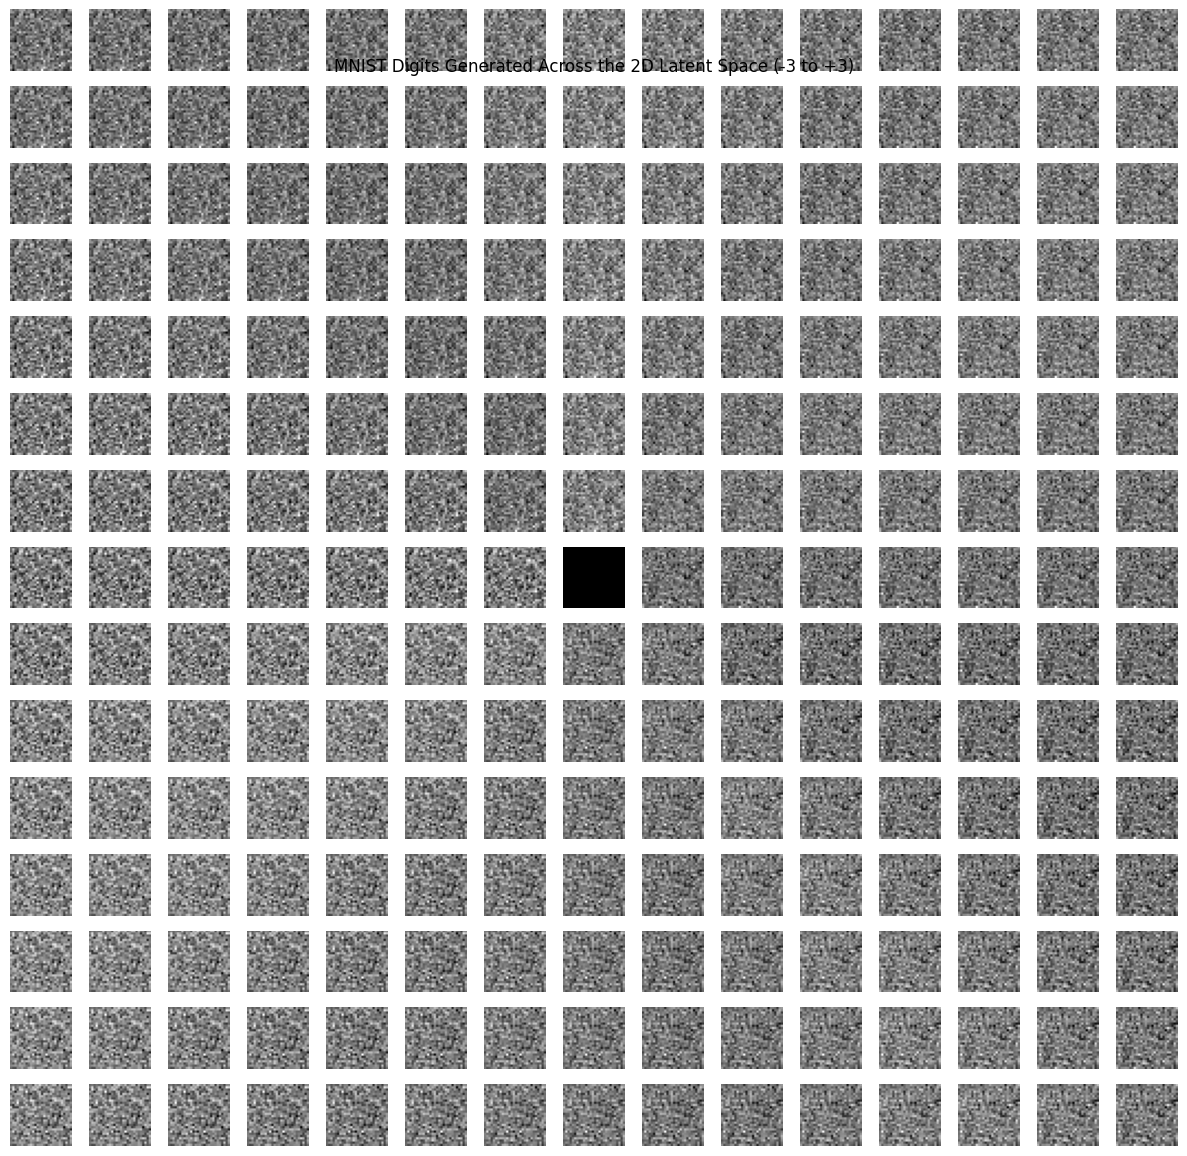

In [21]:
# 13. Decode a grid of latent points from -3 to +3
grid_size = 15
latent_range = np.linspace(-3, 3, grid_size)

latent_points = np.array(
    [[x, y] for y in latent_range[::-1] for x in latent_range],
    dtype=np.float32,
)

generated = decoder.predict(latent_points, verbose=0)

plt.figure(figsize=(12, 12))
for i in range(grid_size * grid_size):
    plt.subplot(grid_size, grid_size, i + 1)
    plt.imshow(generated[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle(
    "MNIST Digits Generated Across the 2D Latent Space (-3 to +3)",
    y=0.92,
)
plt.tight_layout()
plt.show()

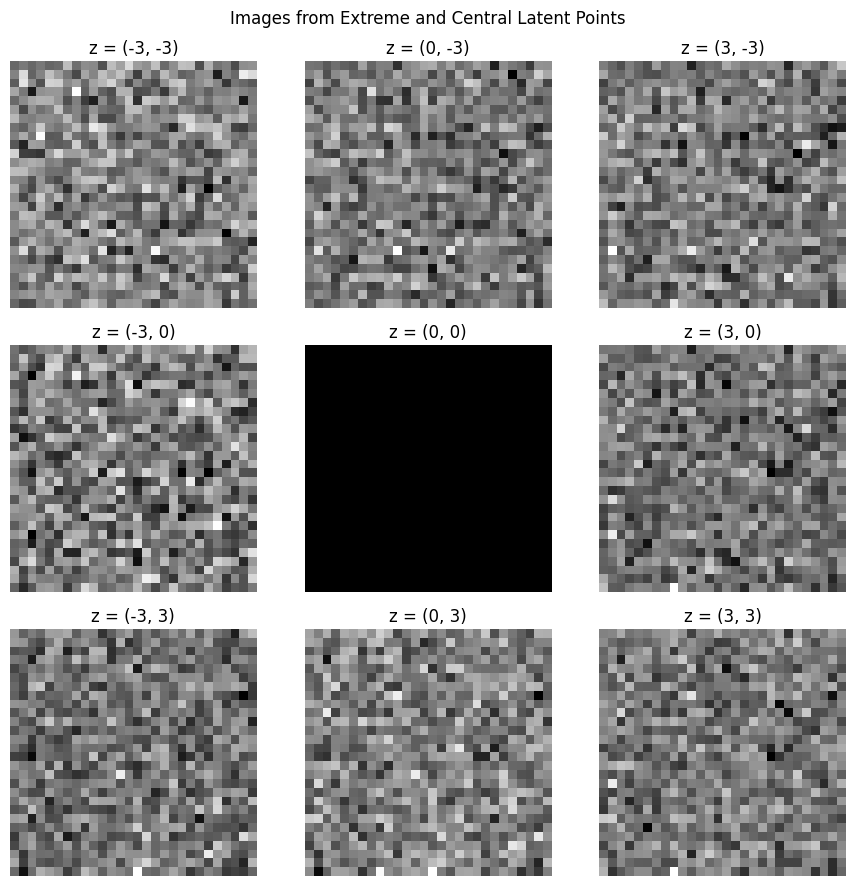

In [22]:
# 14. Generate images from extreme and central latent points
extreme_points = np.array(
    [
        [-3, -3], [0, -3], [3, -3],
        [-3,  0], [0,  0], [3,  0],
        [-3,  3], [0,  3], [3,  3],
    ],
    dtype=np.float32,
)

extreme_images = decoder.predict(extreme_points, verbose=0)

plt.figure(figsize=(9, 9))
for i, point in enumerate(extreme_points):
    plt.subplot(3, 3, i + 1)
    plt.imshow(extreme_images[i].squeeze(), cmap="gray")
    plt.title(f"z = ({point[0]:.0f}, {point[1]:.0f})")
    plt.axis("off")

plt.suptitle("Images from Extreme and Central Latent Points")
plt.tight_layout()
plt.show()